# 1 Initialize the Database

All the code related to data management is in the `EnvironmentData` class. This makes life easier - for example: we can send the CatsUserID once and it becomes a class property. Then, when we call other operations we don't have to send this information again.

When you create a new instance of `EnvironmentData` and there is no database, it will pull historical data and initialize the database. 

In [1]:
# Clear prior data. 
import os
import shutil
from EnvironmentData import EnvironmentData 

# The project adds to existing data so we need to clear that data to get a solid test from scratch.
if os.path.exists('data'):
    shutil.rmtree('data')
    os.makedirs('data')

# Initialize EnvironmentData. This will run the historical data pull.
envdt = EnvironmentData(
    CatsUserID = 2496, 
    days_back = 365 * 2,
    out_of_scope = ['-80', 'Cryo tank', 'Water'],
    coris_enabled = True,
    hobolink_enabled = True,
    conserv_enabled = False, # out of scope for this project (just adding Hobolink). 
    testing = True
)

DEBUG: Enabled data sources: ['Coris', 'Hobolink']


Gathering Hobolink readings: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:06<00:00,  1.58s/it]


Detailed information is saved in the log:

In [2]:
# Detailed info is saved in the log.
with open('data/EnvironmentData.log', 'r') as file:
    for line in file.read().splitlines()[:10]:
        print(line)

2025-11-04 17:30:22,990 - EnvironmentData - INFO - Created Hobolink client
2025-11-04 17:30:22,991 - EnvironmentData - INFO - Enabled data sources: ['Coris', 'Hobolink']
2025-11-04 17:30:22,991 - EnvironmentData - INFO - API call: https://cats.corismonitoring.com/api/cats/user/?ApiKey=XXXX&CatsUserID=XXXX
2025-11-04 17:30:25,256 - EnvironmentData - INFO - API call: https://cats.corismonitoring.com/api/sensor/historical/?ApiKey=XXXX&SensorID=21373&ReadingType=SensorReadingF&StartUTC=1699230622&EndUTC=1762302622&MinReadingSpacing=600&RequestedOutputFormat=raw
2025-11-04 17:30:32,585 - EnvironmentData - INFO - API call: https://cats.corismonitoring.com/api/sensor/historical/?ApiKey=XXXX&SensorID=21375&ReadingType=SensorReadingF&StartUTC=1699230622&EndUTC=1762302622&MinReadingSpacing=600&RequestedOutputFormat=raw
2025-11-04 17:30:39,057 - EnvironmentData - INFO - API call: https://cats.corismonitoring.com/api/sensor/historical/?ApiKey=XXXX&SensorID=21377&ReadingType=SensorReadingF&StartUTC

This saves our intermediate data to `data/sensor_readings.parquet`. 

Initially, we leave the data mostly as-is. We'll clean, add formatted dates, consolidate readings from the same device, etc. when moving to analytical steps, this preserves the source data so we can always change our mind later about how we decide to view it. 

However, at this point we are taking care to standardize the data format between different API sources. 

There are just a few columns because this is only historical data. We'll bring in current data shortly, and that will add more columns. 

In [3]:
import polars
polars.read_parquet('data/sensor_readings.parquet').filter(polars.col("Source") == "Coris").head()

SensorReadingUTC,Source,DeviceID,DeviceName,SensorID,SensorName,SensorType,SensorReadingF,SensorReadingRh
i64,str,str,str,str,str,str,f32,f32
1699230622,"""Coris""","""coris:12162""","""Peabody TH-L Mammal Hall D444""","""coris:21373""","""PYPM__0100104SET____ Temp YPM …","""Temperature""",69.889999,null
1699231222,"""Coris""","""coris:12162""","""Peabody TH-L Mammal Hall D444""","""coris:21373""","""PYPM__0100104SET____ Temp YPM …","""Temperature""",69.839996,null
1699231822,"""Coris""","""coris:12162""","""Peabody TH-L Mammal Hall D444""","""coris:21373""","""PYPM__0100104SET____ Temp YPM …","""Temperature""",69.849998,null
1699232422,"""Coris""","""coris:12162""","""Peabody TH-L Mammal Hall D444""","""coris:21373""","""PYPM__0100104SET____ Temp YPM …","""Temperature""",69.849998,null
1699233022,"""Coris""","""coris:12162""","""Peabody TH-L Mammal Hall D444""","""coris:21373""","""PYPM__0100104SET____ Temp YPM …","""Temperature""",69.889999,null


In [4]:
polars.read_parquet('data/sensor_readings.parquet').filter(polars.col("Source") == "Hobolink").head()

SensorReadingUTC,Source,DeviceID,DeviceName,SensorID,SensorName,SensorType,SensorReadingF,SensorReadingRh
i64,str,str,str,str,str,str,f32,f32
1736345700,"""Hobolink""","""hobolink:22202141""","""RX Station 2""","""hobolink:22202141-22179174-1""",null,"""Temperature""",68.674843,null
1736374500,"""Hobolink""","""hobolink:22202141""","""RX Station 2""","""hobolink:22202141-22179174-1""",null,"""Temperature""",66.975983,null
1736377200,"""Hobolink""","""hobolink:22202141""","""RX Station 2""","""hobolink:22202141-22179174-1""",null,"""Temperature""",70.528137,null
1736379000,"""Hobolink""","""hobolink:22202141""","""RX Station 2""","""hobolink:22202141-22179174-1""",null,"""Temperature""",70.682579,null
1736380800,"""Hobolink""","""hobolink:22202141""","""RX Station 2""","""hobolink:22202141-22179174-1""",null,"""Temperature""",70.798409,null


# 2 Get Current Readings

Now we can start gathering and appending readings. There is a function `get_current_readings` that is run throughout the day, every 10 minutes for example. This function creates a parquet file at `data/new-readings` with the UTC as a filename. At the end of the day, all these readings will be consolidated into the database. 

Here is a sample of the readings:

In [5]:
envdt.get_current_readings()

# Data is read into new-readings folder for consolidation at the end of the day.
import os
filename = os.listdir('data/new-readings')[0]
print(filename)
polars.read_parquet('data/new-readings/' + filename).sample(5)

C:\Users\Bryce\Documents\arbaiza\environmental-sensor-poc\EnvironmentData.py:220: UserWarning: get_current_readings_coris validation errors : SensorReadingUTC is 5 minutes old

  warnings.warn(msg)


1762302675.parquet


SensorReadingUTC,Source,DeviceID,DeviceName,SensorID,SensorName,SensorType,SensorReadingF,SensorReadingRh,QueryUTC
i64,str,str,str,str,str,str,f32,f32,i32
1762302368,"""Coris""","""coris:12169""","""Peabody TH-L Diorama Room 304 …","""coris:21375""","""PYPM__0300302SET____ Temp YPM …","""Temperature""",68.099998,null,1762302675
1762302678,"""Hobolink""","""hobolink:22202142""","""RX Station 1""","""hobolink:22202142-22179174-1""","""RX Station 1_Temperature""","""Temperature""",70.45092,null,1762302677
1762302464,"""Coris""","""coris:12162""","""Peabody TH-L Mammal Hall D444""","""coris:21373""","""PYPM__0100104SET____ Temp YPM …","""Temperature""",68.300003,null,1762302675
1762302655,"""Coris""","""coris:12167""","""Peabody TH-L Upper Great Hall …","""coris:21378""","""PKGL__LL00021SCI____ RH KGL 21…","""Humidity""",null,42.689999,1762302675
1762302464,"""Coris""","""coris:12162""","""Peabody TH-L Mammal Hall D444""","""coris:21374""","""PYPM__0100104SET____ RH YPM 10…","""Humidity""",null,53.970001,1762302675


# 3 Consolidate Readings

At the end of the day, new readings will be consolidated into the table. At the same time, the analytical tables will be generated. 

Analytical tables include:

* `device_readings.parquet`: Sensor readings reorganized to one row per Device and UTC, with measurements across columns vs measurements across rows.* 
* `sensors.parquet`: Information about the unique sensors. Includes information extracted from SensorName. Join this to Sensors during analysis to enhance with Building, Room, Direction, etc.
* `devices.parquet`: Information about unique devices. Includes information extracted from SensorName. 
* `utcs.parquet`: Information related to the UTC times in various datasets. Join to Sensors or Devices to enhance with Date, Time, Year, Hour, Weekday, etc.
* `sensor_readings_daily.parquet`: Example of sensor readings summarized to the daily level which reduces row count by 99.3% for even faster queries.
* `device_readings_daily.parquet`: Example of device readings summarized to the daily level which reduces row count by 99.3% for even faster queries. 

We fully re-generate analytical tables during each consolidation. The data is small enough that this is a fairly quick process, so re-running it in full each time will make it easy to ensure consistency as we expand and change the project. 

In [6]:
# To consolidate these into the database, run consolidate_readings.
envdt.consolidate_readings()

# New-readings files are gone now.
# They get deleted each day to confirm that they have been loaded into the database and prepare for the next consolidation.
print(os.listdir('data/new-readings'))

C:\Users\Bryce\Documents\arbaiza\environmental-sensor-poc\EnvironmentData.py:220: UserWarning: consolidate_readings validation errors : Count of sensors missing from historical data: 38.

  warnings.warn(msg)


[]


**^^ We want this to be empty** since we have consolidated new readings into the historical data. 

Let's look at the data we have now:

In [7]:
# Sensor Readings
# The first rows will be missing the extra fields like HexGatewayMac, etc.
#   I am pulling in some extra fields like DeviceID and DeviceName so we have that by historical. 
#   But some don't make sense to  backfill so they'll be null.
sensor_readings = polars.read_parquet('data/sensor_readings.parquet')
sensor_readings.head()

SensorReadingUTC,Source,DeviceID,DeviceName,SensorID,SensorName,SensorType,SensorReadingF,SensorReadingRh,QueryUTC,SensorReadingUTC_SecondsFromPrior
i64,str,str,str,str,str,str,f32,f32,i32,i64
1699230622,"""Coris""","""coris:12162""","""Peabody TH-L Mammal Hall D444""","""coris:21373""","""PYPM__0100104SET____ Temp YPM …","""Temperature""",69.889999,null,null,null
1699231222,"""Coris""","""coris:12162""","""Peabody TH-L Mammal Hall D444""","""coris:21373""","""PYPM__0100104SET____ Temp YPM …","""Temperature""",69.839996,null,null,600
1699231822,"""Coris""","""coris:12162""","""Peabody TH-L Mammal Hall D444""","""coris:21373""","""PYPM__0100104SET____ Temp YPM …","""Temperature""",69.849998,null,null,600
1699232422,"""Coris""","""coris:12162""","""Peabody TH-L Mammal Hall D444""","""coris:21373""","""PYPM__0100104SET____ Temp YPM …","""Temperature""",69.849998,null,null,600
1699233022,"""Coris""","""coris:12162""","""Peabody TH-L Mammal Hall D444""","""coris:21373""","""PYPM__0100104SET____ Temp YPM …","""Temperature""",69.889999,null,null,600


In [8]:
# Recent rows will have the full data, aside from nulls due to a sensor not providing a reading type.
sensor_readings.tail()

SensorReadingUTC,Source,DeviceID,DeviceName,SensorID,SensorName,SensorType,SensorReadingF,SensorReadingRh,QueryUTC,SensorReadingUTC_SecondsFromPrior
i64,str,str,str,str,str,str,f32,f32,i32,i64
1762299900,"""Hobolink""","""hobolink:22202142""","""RX Station 1""","""hobolink:22202142-22179175-2""",null,"""RH""",null,42.917526,null,900
1762300800,"""Hobolink""","""hobolink:22202142""","""RX Station 1""","""hobolink:22202142-22179175-2""",null,"""RH""",null,42.610817,null,900
1762301700,"""Hobolink""","""hobolink:22202142""","""RX Station 1""","""hobolink:22202142-22179175-2""",null,"""RH""",null,46.91539,null,900
1762302600,"""Hobolink""","""hobolink:22202142""","""RX Station 1""","""hobolink:22202142-22179175-2""",null,"""RH""",null,41.791409,null,900
1762302678,"""Hobolink""","""hobolink:22202142""","""RX Station 1""","""hobolink:22202142-22179175-2""","""RX Station 1_RH""","""RH""",null,41.791409,1762302677,78


In [9]:
# Device Readings.
device_readings = polars.read_parquet('data/device_readings.parquet')
device_readings.head()

DeviceID,DeviceName,SensorReadingUTC,QueryUTC,SensorReadingF,SensorReadingRh
str,str,i64,i32,f32,f32
"""coris:12162""","""Peabody TH-L Mammal Hall D444""",1699230622,null,69.889999,null
"""coris:12162""","""Peabody TH-L Mammal Hall D444""",1699231222,null,69.839996,null
"""coris:12162""","""Peabody TH-L Mammal Hall D444""",1699231822,null,69.849998,null
"""coris:12162""","""Peabody TH-L Mammal Hall D444""",1699232422,null,69.849998,null
"""coris:12162""","""Peabody TH-L Mammal Hall D444""",1699233022,null,69.889999,null


In [10]:
# Sensors
sensors = polars.read_parquet('data/sensors.parquet')
sensors.head()

SensorID,SensorName,SensorType,DeviceID,DeviceSerialFromName,BuildingID,Building,Room,CardinalDirection
str,str,str,str,str,str,str,str,str
"""hobolink:10740550-10740550-2""","""ICSC__010C149________RH""","""RH""","""hobolink:10740550""","""RH""","""FLOATER""","""Unknown""","""FLOATER""",null
"""hobolink:10740550-10740550-1""","""ICSC__010C149________Temperatu…","""Temperature""","""hobolink:10740550""","""Temperature""","""FLOATER""","""Unknown""","""FLOATER""",null
"""coris:21378""","""RH KGL 21_D0B2""","""Humidity""","""coris:12167""","""D0B2""","""KGL""","""Kline Geology Laboratory""","""21""","""Not Indicated"""
"""coris:21377""","""Temp KGL 21_D0B2""","""Temperature""","""coris:12167""","""D0B2""","""KGL""","""Kline Geology Laboratory""","""21""","""Not Indicated"""
"""hobolink:22202142-22179174-2""","""RX Station 1_RH""","""RH""","""hobolink:22202142""","""RH""","""Station""","""Unknown""","""1""","""Not Indicated"""


In [11]:
# Devices. 
devices = polars.read_parquet('data/devices.parquet')
devices.head()

DeviceID,DeviceName,DeviceSerialFromName,BuildingID,Building,Room,CardinalDirection
str,str,str,str,str,str,str
"""hobolink:10740550""","""ICSC__010C149_______""","""Temperature""","""FLOATER""","""Unknown""","""FLOATER""",null
"""coris:12167""","""Peabody TH-L Upper Great Hall …","""D0B2""","""KGL""","""Kline Geology Laboratory""","""21""","""Not Indicated"""
"""hobolink:22202142""","""RX Station 1""","""Temperature""","""Station""","""Unknown""","""1""","""Not Indicated"""
"""hobolink:22202141""","""RX Station 2""","""Temperature""","""Station""","""Unknown""","""2""","""Not Indicated"""
"""coris:12162""","""Peabody TH-L Mammal Hall D444""","""D444""","""YPM""","""Yale Peabody Museum""","""104""","""Not Indicated"""


In [12]:
# UTC Date/Time Info
utcs = polars.read_parquet('data/utcs.parquet').head()
utcs.head()

UTC,datetime_utc,datetime_est,date,time,year,month,day_of_week,day_of_week_monday1_sunday7,hour_24,hour_12,am_pm
i64,datetime[μs],"datetime[μs, America/New_York]",date,time,i32,i8,str,i8,i8,i8,str
1699230622,2023-11-05 17:30:22,2023-11-05 12:30:22 EST,2023-11-05,12:30:22,2023,11,"""Sunday""",7,12,0,"""PM"""
1699231222,2023-11-05 17:40:22,2023-11-05 12:40:22 EST,2023-11-05,12:40:22,2023,11,"""Sunday""",7,12,0,"""PM"""
1699231822,2023-11-05 17:50:22,2023-11-05 12:50:22 EST,2023-11-05,12:50:22,2023,11,"""Sunday""",7,12,0,"""PM"""
1699232422,2023-11-05 18:00:22,2023-11-05 13:00:22 EST,2023-11-05,13:00:22,2023,11,"""Sunday""",7,13,1,"""PM"""
1699233022,2023-11-05 18:10:22,2023-11-05 13:10:22 EST,2023-11-05,13:10:22,2023,11,"""Sunday""",7,13,1,"""PM"""


In [13]:
# Daily Sensor Readings
# Averages are calculated by summing the "sum" and "row_count" columns and dividing to get the average. 
sensor_readings_daily = polars.read_parquet('data/sensor_readings_daily.parquet')
sensor_readings_daily.head()

date,SensorID,row_count,SensorReadingF_sum,SensorReadingRh_sum,SensorReadingF_min,SensorReadingRh_min,SensorReadingF_max,SensorReadingRh_max
date,str,u32,f32,f32,f32,f32,f32,f32
2025-11-04,"""coris:21373""",1,68.300003,0.0,68.300003,null,68.300003,null
2025-11-04,"""coris:21374""",1,0.0,53.970001,null,53.970001,null,53.970001
2025-11-04,"""coris:21377""",1,71.099998,0.0,71.099998,null,71.099998,null
2025-11-04,"""coris:21378""",1,0.0,42.689999,null,42.689999,null,42.689999
2025-11-04,"""hobolink:10740550-10740550-1""",1,67.370972,0.0,67.370972,null,67.370972,null


In [14]:
# Daily Device Readings
# Averages are calculated by summing the "sum" and "row_count" columns and dividing to get the average. 
device_readings_daily = polars.read_parquet('data/device_readings_daily.parquet')
device_readings_daily.head()

date,DeviceID,row_count,SensorReadingF_sum,SensorReadingRh_sum,SensorReadingF_min,SensorReadingRh_min,SensorReadingF_max,SensorReadingRh_max
date,str,u32,f32,f32,f32,f32,f32,f32
2025-11-04,"""coris:12162""",1,68.300003,53.970001,68.300003,53.970001,68.300003,53.970001
2025-11-04,"""coris:12167""",1,71.099998,42.689999,71.099998,42.689999,71.099998,42.689999
2025-11-04,"""hobolink:10740550""",1,67.370972,48.995911,67.370972,48.995911,67.370972,48.995911
2025-11-04,"""hobolink:22202141""",1,70.103424,10.269321,70.103424,10.269321,70.103424,10.269321
2025-11-04,"""hobolink:22202142""",4,282.421448,165.874725,70.45092,41.145954,70.759804,41.791409


Once we are done working with data intake/processing, we close the class to release lgo file connections:

In [15]:
# When done, close the connection to the logs. 
envdt.close()

# 4 Analytics

Now we are ready to pull data and run analytics. Here are a few examples: 

<Axes: ylabel='Count'>

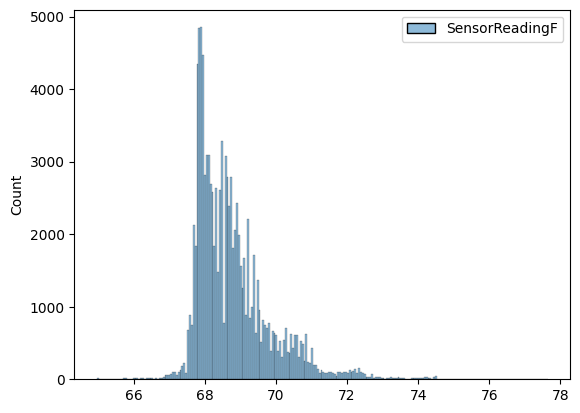

In [16]:
# Histogram of temperature. 
import seaborn
import duckdb
dt = duckdb.sql("""
    SELECT SensorReadingF 
    FROM read_parquet('data/sensor_readings.parquet') 
    WHERE SensorReadingF is not null and SensorID = 'coris:21373';
""")
seaborn.histplot(dt.fetchnumpy())

<Axes: xlabel='SensorReadingUTC', ylabel='SensorReadingF'>

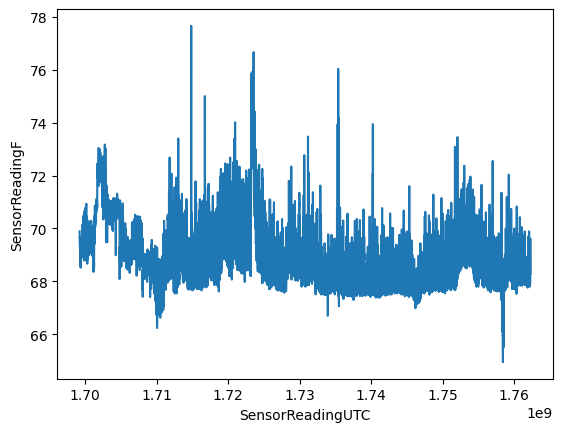

In [17]:
# Time series plot. 
dt = duckdb.sql("""
    SELECT SensorReadingUTC, SensorReadingF 
    FROM read_parquet('data/sensor_readings.parquet') 
    WHERE SensorReadingF is not null and SensorID = 'coris:21373';
""")
seaborn.lineplot(x = 'SensorReadingUTC', y= 'SensorReadingF', data=dt.fetchnumpy())

<Axes: xlabel='SensorReadingUTC', ylabel='SensorReadingF'>

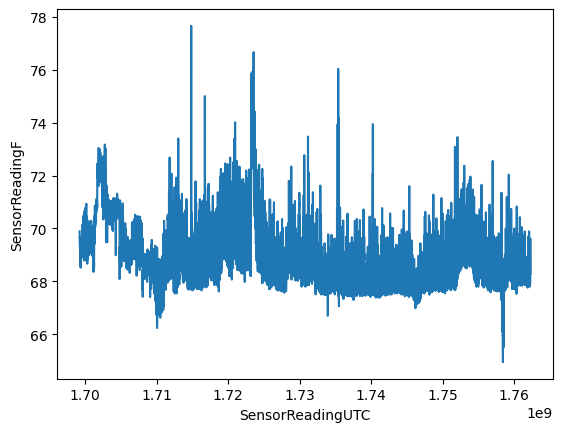

In [18]:
# Time series plot, queried from Devices instead of Sensors. 
# This is the same data, just organized in a different way. 
dt = duckdb.sql("""
    SELECT SensorReadingUTC, SensorReadingF 
    FROM read_parquet('data/device_readings.parquet') 
    WHERE SensorReadingF is not null and DeviceID = 'coris:12162';
""")
seaborn.lineplot(x = 'SensorReadingUTC', y= 'SensorReadingF', data=dt.fetchnumpy())

In [19]:
# Differentiate historical vs. cron readings by filtering on QueryUTC = NULL.
duckdb.sql("""
    SELECT *
    FROM read_parquet('data/device_readings.parquet') 
    WHERE QueryUTC is null
""")

┌─────────────┬───────────────────────────────┬──────────────────┬──────────┬────────────────┬─────────────────┐
│  DeviceID   │          DeviceName           │ SensorReadingUTC │ QueryUTC │ SensorReadingF │ SensorReadingRh │
│   varchar   │            varchar            │      int64       │  int32   │     float      │      float      │
├─────────────┼───────────────────────────────┼──────────────────┼──────────┼────────────────┼─────────────────┤
│ coris:12162 │ Peabody TH-L Mammal Hall D444 │       1699230622 │     NULL │          69.89 │            NULL │
│ coris:12162 │ Peabody TH-L Mammal Hall D444 │       1699231222 │     NULL │          69.84 │            NULL │
│ coris:12162 │ Peabody TH-L Mammal Hall D444 │       1699231822 │     NULL │          69.85 │            NULL │
│ coris:12162 │ Peabody TH-L Mammal Hall D444 │       1699232422 │     NULL │          69.85 │            NULL │
│ coris:12162 │ Peabody TH-L Mammal Hall D444 │       1699233022 │     NULL │          69.89 │  